# Assignment 2: Metabolic Modeling

## Part1: Visualizing reaction maximal activity data and making some sense of it.

a) No, the maximal reactions are not equal in a linear pathway, for example between PGM and ENO, there's a difference in the maximal reactions. The maximal reaction of PGM is 21.7, while the maximal reaction of ENO is 29.3. this is because the maximal reactions is the vmax, in other words the maximal number of reactions that can occur depending on the enzyme capacity, and this might be different for adjacent enzymes in a linear pathway.

b) The two possible values that the grey arrows can have are 0.00 or n.d. The difference is that 0.00 means that data for this reaction was collected and it was 0.00, which might mean that that gene is not expressed in the cell. While n.d. means "no data", which might mean that the data for this reaction is not in the loaded dataset.

## Part2: Adjusting upper and lower bounds.

In [1]:
import sys

In [2]:
!{sys.executable} -m pip install cobra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 11.5 MB/s  0:00:011.7 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 10.5 MB/s  0:00:000.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 6.0 MB/s  0:00:00m 29.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 11.5 MB/s  0:00:001.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 10.3 MB/s  0:00:00
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 17/26 [pydantic]dantic-core]
    Found existing installation: pandas 3.0.50m╺━━━━━━━━━━━━━ 17/26 [pydantic]
    Uninstalling pandas-3.0.5:━━━━━━━━━━━━━╺━━━━━━━━━━━━━ 17/26 [pydantic]
      Successfully uninstalled pandas-3.0.5╺━━━━━━━━━━━━━ 17/26 [pydantic]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26 [cobra];5;237m━━━ 2

In [3]:
# Import for libraries used (with installatioin)
import cobra
import csv

In [4]:
# loading the ecoli model taken from the computer practical.
model = cobra.io.load_json_model('e_coli_core-1.json')

In [5]:
# csv file with reaction activity
filename = "KEN3170_Assignment_2026_e_coli_core_expression.csv"

In [6]:
# reading the csv file and saving the values in activity_constraints to be used later
activity_constraints = {}

with open(filename, mode="r", newline="") as file:
    reader = csv.reader(file)

    for row in reader:
        if not row or row[0].startswith("#"):
            continue

        reaction_id = row[0]
        value = float(row[1])

        activity_constraints[reaction_id] = value

In [7]:
#setting lower and upper bounds according to instructions provided and with activity data taken from the csv file
for reaction in model.reactions:
    
    reaction_id = reaction.id

    if reaction_id in activity_constraints: #This makes sure we only chnage the bounds for reactions with data

        #we will use this to change bounds to their activity data (when applicable)
        value = activity_constraints[reaction_id]

        # if ATPM energy mainenance
        if reaction_id == "ATPM":
            reaction.upper_bound = value

        # if reversible reaction
        elif reaction.lower_bound < 0:
            reaction.lower_bound = -value
            reaction.upper_bound = value

        #if irreversable reaction
        else:
            reaction.upper_bound = value

    # if glucose exchange reaction
    elif reaction_id == "EX_glc__D_e":
        reaction.lower_bound = -1000
        reaction.upper_bound = 1000
        

In [8]:
#print out for a table with each reaction's lower and uppoer flux bound
print("reaction lowerB upperB")
for reaction in model.reactions:
    print(
        reaction.id,
        reaction.lower_bound,
        reaction.upper_bound
    )

reaction lowerB upperB
PFK 0.0 13.1
PFL 0.0 0.0
PGI -11.1 11.1
PGK -24.0 24.0
PGL 0.0 7.3
ACALD -0.0 0.0
AKGt2r -0.0 0.0
PGM -21.7 21.7
PIt2r -5.2 5.2
ALCD2x -0.0 0.0
ACALDt -1000.0 1000.0
ACKr -2.5 2.5
PPC 0.0 3.6
ACONTa -21.4 21.4
ACONTb -21.4 21.4
ATPM 8.39 1000.0
PPCK 0.0 13.3
ACt2r -3.6 3.6
PPS 0.0 3.1
ADK1 -27.4 27.4
AKGDH 0.0 26.7
ATPS4r -80.1 80.1
PTAr -4.47 4.47
PYK 0.0 28.2
BIOMASS_Ecoli_core_w_GAM 0.0 1000.0
PYRt2 -0.0 0.0
CO2t -1000.0 1000.0
RPE -6.3 6.3
CS 0.0 21.4
RPI -5.6 5.6
SUCCt2_2 0.0 0.0
CYTBD 0.0 41.1
D_LACt2 -0.0 0.0
ENO -29.3 29.3
SUCCt3 0.0 0.0
ETOHt2r -1000.0 1000.0
SUCDi 0.0 27.3
SUCOAS -19.4 19.4
TALA -4.5 4.5
THD2 0.0 6.5
TKT1 -3.5 3.5
TKT2 -3.5 3.5
TPI -70.0 70.0
EX_ac_e 0.0 1000.0
EX_acald_e 0.0 1000.0
EX_akg_e 0.0 1000.0
EX_co2_e -1000.0 1000.0
EX_etoh_e 0.0 1000.0
EX_for_e 0.0 1000.0
EX_fru_e 0.0 1000.0
EX_fum_e 0.0 1000.0
EX_glc__D_e -1000 1000
EX_gln__L_e 0.0 1000.0
EX_glu__L_e 0.0 1000.0
EX_h_e -1000.0 1000.0
EX_h2o_e -1000.0 1000.0
EX_lac__D_e 0.0 10

## Part3: Flux Balance Analysis, absolute flux bound and FBA biomass.

In [8]:
# 3a
# optimize the model for biomass production
solution = model.optimize()

# print maximal biomass production
print("Maximal biomass production:", solution.objective_value)



Maximal biomass production: 0.8732862458582654


In [9]:
# 3b
# setting the absolute flux bound for the glucose exchange reaction lower bound to 5.0
# in cobrapy the flux is defined so that the intake into the cell has a negative sign
model.reactions.get_by_id("EX_glc__D_e").lower_bound = -5.0

3b) this constraint describes an upper limit in the intake rate of glucose into the cell (extracellular). Whereas the other expression-based constraints decribe bounds on the internal reaction rates of the metabolites in the cell (intracellular).

In [10]:
# 3c
# optimize the model for biomass production with the new glucose intake constraint
solution = model.optimize()
print("Maximal biomass production with new glucose intake constraint:", solution.objective_value)

Maximal biomass production with new glucose intake constraint: 0.41559777509290613


## Part4: Maximal Biomass vs. Glucose Uptake

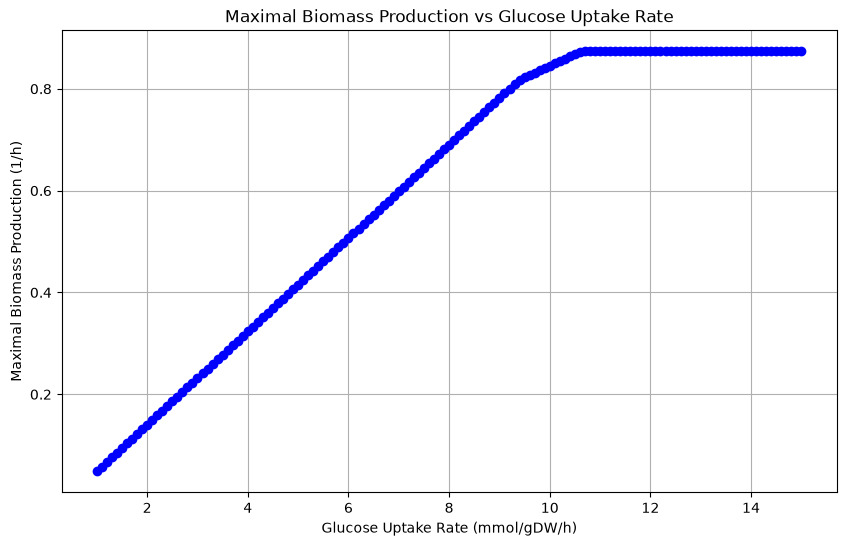

In [9]:
# 4a
import numpy as np
import matplotlib.pyplot as plt

glucose_uptake_rates = np.arange(1, 15.1, 0.1) # from 1 to 15 with a step of 0.1

biomass_values = []

for rate in glucose_uptake_rates:
    model.reactions.get_by_id("EX_glc__D_e").lower_bound = -rate
    solution = model.optimize()
    biomass_values.append(solution.objective_value)

plt.figure(figsize=(10, 6))
plt.plot(glucose_uptake_rates, biomass_values, marker='o', linestyle='-', color='b')
plt.xlabel("Glucose Uptake Rate (mmol/gDW/h)")
plt.ylabel("Maximal Biomass Production (1/h)")
plt.title("Maximal Biomass Production vs Glucose Uptake Rate")
plt.grid(True)  
plt.show()

In [17]:
print(biomass_values)

[0.04838497229681496, 0.05767956082803632, 0.06697414935925763, 0.07626873789047897, 0.08556332642170034, 0.09477116278003904, 0.10393763741754959, 0.1131041120550601, 0.12227058669257064, 0.13143706133008107, 0.14060353596759154, 0.14977001060510212, 0.15893648524261272, 0.16810295988012308, 0.17726943451763347, 0.186435909155144, 0.19560238379265454, 0.20476885843016518, 0.2139353330676757, 0.22310180770518614, 0.2322682823426966, 0.2414347569802072, 0.25060123161771747, 0.25976770625522805, 0.26893418089273863, 0.278100655530249, 0.2872671301677595, 0.29643360480527015, 0.30560007944278045, 0.31476655408029114, 0.3239330287178016, 0.333099503355312, 0.34226597799282277, 0.35143245263033307, 0.3605989272678436, 0.36976540190535406, 0.3789318765428644, 0.38809835118037517, 0.39726482581788575, 0.40643130045539616, 0.41559777509290646, 0.42476424973041693, 0.4339307243679276, 0.4430971990054381, 0.4522636736429483, 0.4614301482804589, 0.47059662291796955, 0.4797630975554799, 0.48892957

In [10]:
print("Limit: " + str(max(biomass_values)))
print("Limit is reached at glucose uptake rate: " + str(glucose_uptake_rates[np.argmax(biomass_values)]))

Limit: 0.8732862458582383
Limit is reached at glucose uptake rate: 10.800000000000008


In [23]:
biomass_rates = np.asarray(biomass_values, dtype=float).ravel()

delta_biomass = np.diff(biomass_rates)

print("Rate   Previous biomass   Current biomass   Change")
print("-" * 65)

for i, change in enumerate(delta_biomass, start=1):
    print(
        f"{glucose_uptake_rates[i]:<10.2f}"
        f"{biomass_rates[i-1]:>18.6f}"
        f"{biomass_rates[i]:>18.6f}"
        f"{change:>14.6f}"
    )


Rate   Previous biomass   Current biomass   Change
-----------------------------------------------------------------
1.10                0.048385          0.057680      0.009295
1.20                0.057680          0.066974      0.009295
1.30                0.066974          0.076269      0.009295
1.40                0.076269          0.085563      0.009295
1.50                0.085563          0.094771      0.009208
1.60                0.094771          0.103938      0.009166
1.70                0.103938          0.113104      0.009166
1.80                0.113104          0.122271      0.009166
1.90                0.122271          0.131437      0.009166
2.00                0.131437          0.140604      0.009166
2.10                0.140604          0.149770      0.009166
2.20                0.149770          0.158936      0.009166
2.30                0.158936          0.168103      0.009166
2.40                0.168103          0.177269      0.009166
2.50                0.177269 

4b) No, the growth rate does not increase indefinitely with increasing glucose exchange reaction flux bound. Maximal Biomass Production increases with glucose uptake until glucose uptake rate is around 10 mmol/gDW/h. After that, the line starts to flatten, which means that it stops increasing even when glucose increases.

In [26]:
# 4c
exchange_ids = [reaction.id for reaction in model.exchanges]
print(exchange_ids)

['EX_ac_e', 'EX_acald_e', 'EX_akg_e', 'EX_co2_e', 'EX_etoh_e', 'EX_for_e', 'EX_fru_e', 'EX_fum_e', 'EX_glc__D_e', 'EX_gln__L_e', 'EX_glu__L_e', 'EX_h_e', 'EX_h2o_e', 'EX_lac__D_e', 'EX_mal__L_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e', 'EX_succ_e']


In [31]:
# 4c

for r in [9.3, 9.4, 9.5]:

    print(f"\nGlucose uptake rate: {r}")

    model.reactions.get_by_id("EX_glc__D_e").lower_bound = -r
    solution = model.optimize()

    print("Maximal biomass production with glucose uptake rate of 10:")
    for reaction in model.reactions:
        if reaction.id.startswith("EX_"):
            flux_value = solution.fluxes[reaction.id]
            print(f"{reaction.id}: {flux_value}")
    print("=================================================================")


Glucose uptake rate: 9.3
Maximal biomass production with glucose uptake rate of 10:
EX_ac_e: 0.0
EX_acald_e: 0.0
EX_akg_e: 0.0
EX_co2_e: 21.34042069026107
EX_etoh_e: 0.0
EX_for_e: 0.0
EX_fru_e: 0.0
EX_fum_e: 0.0
EX_glc__D_e: -9.3
EX_gln__L_e: 0.0
EX_glu__L_e: 0.0
EX_h_e: 16.243709061187534
EX_h2o_e: 27.239008640675493
EX_lac__D_e: 0.0
EX_mal__L_e: 0.0
EX_nh4_e: -4.415438522873542
EX_o2_e: -20.40426156535382
EX_pi_e: -2.9788500759416956
EX_pyr_e: 0.0
EX_succ_e: 0.0

Glucose uptake rate: 9.4
Maximal biomass production with glucose uptake rate of 10:
EX_ac_e: 0.05367170526640651
EX_acald_e: 0.0
EX_akg_e: 0.0
EX_co2_e: 21.495334540101087
EX_etoh_e: 0.0
EX_for_e: 0.0
EX_fru_e: 0.0
EX_fum_e: 0.0
EX_glc__D_e: -9.4
EX_gln__L_e: 0.0
EX_glu__L_e: 0.0
EX_h_e: 16.456587434379827
EX_h2o_e: 27.451735304665057
EX_lac__D_e: 0.0
EX_mal__L_e: 0.0
EX_nh4_e: -4.458714799985513
EX_o2_e: -20.549999999999997
EX_pi_e: -3.0080461661360474
EX_pyr_e: 0.0
EX_succ_e: 0.0

Glucose uptake rate: 9.5
Maximal biomass 

At glucose uptake equal to 10 EX_o2_e equals to -20.55, which means that oxygen uptake hit its bound and EX_ac_e equals to 1.25, whcih means that acetate is being excreted. That is why the line starts to flatten.

In [32]:
for glucose_rate in glucose_uptake_rates:
    model.reactions.get_by_id("EX_glc__D_e").lower_bound = -glucose_rate

    solution = model.optimize()

    acetate_flux = solution.fluxes["EX_ac_e"]

    print(
        f"Glucose uptake: {glucose_rate:.2f}, "
        f"Acetate exchange: {acetate_flux:.6f}"
    )


Glucose uptake: 1.00, Acetate exchange: 0.000000
Glucose uptake: 1.10, Acetate exchange: 0.000000
Glucose uptake: 1.20, Acetate exchange: 0.000000
Glucose uptake: 1.30, Acetate exchange: 0.000000
Glucose uptake: 1.40, Acetate exchange: 0.000000
Glucose uptake: 1.50, Acetate exchange: 0.000000
Glucose uptake: 1.60, Acetate exchange: 0.000000
Glucose uptake: 1.70, Acetate exchange: 0.000000
Glucose uptake: 1.80, Acetate exchange: 0.000000
Glucose uptake: 1.90, Acetate exchange: 0.000000
Glucose uptake: 2.00, Acetate exchange: 0.000000
Glucose uptake: 2.10, Acetate exchange: 0.000000
Glucose uptake: 2.20, Acetate exchange: 0.000000
Glucose uptake: 2.30, Acetate exchange: 0.000000
Glucose uptake: 2.40, Acetate exchange: 0.000000
Glucose uptake: 2.50, Acetate exchange: 0.000000
Glucose uptake: 2.60, Acetate exchange: 0.000000
Glucose uptake: 2.70, Acetate exchange: 0.000000
Glucose uptake: 2.80, Acetate exchange: 0.000000
Glucose uptake: 2.90, Acetate exchange: 0.000000
Glucose uptake: 3.00

In [33]:
for reaction_id in ["PTAr", "ACKr", "EX_ac_e"]:
    print(reaction_id, solution.fluxes[reaction_id])


PTAr 2.5000000000000004
ACKr -2.5
EX_ac_e 2.5000000000000004
